# ⚛︎ Hyperuniform sampling with the finufft (for 2D/3D point clouds)

# GPU configuration:

- GPU configuration is optional, and definitely *not needed* if the number of sampled points is <= 100k.
- For large datasets, it will make the sampler run much faster than the CPU version.  First select the GPU-T4 runtime of google colab and then install jax-finufft with cuda, which is done by runing the first cell bellow, then restart the kernel, and run the second cell bellow.

In [ ]:
#===============Skip for CPU version (optional). Might take a while ...================

GPU = False
if GPU:
  !pip install -q condacolab
  import condacolab
  condacolab.install()


Transaction finished



In [ ]:
#===============Skip for CPU version (optional) Might take a while...================
# /!\ Restart the kernel before doing that
GPU = False
if GPU:
  import condacolab
  condacolab.check()
  !mamba install -c conda-forge 'jax-finufft=*=cuda*' -y

# Required packages

In [77]:
!pip install blue-sampler jax numpy jax-finufft optax

# Float precision configuration

- float32 always recomanded besides if S(k) << 10^-10 is required.
- The sampler can go as far as S(k) = 10^-20 using float64 computation,
but float64 is SLOW

In [ ]:
import jax

precision = "simple"
if precision == "double":  # Slow -> NOT recommanded for large samples, only if ultra high precision is neaded
    jax.config.update("jax_enable_x64", True)
else:
    jax.config.update("jax_enable_x64", False)

# Sampler

- based on a **spectral loss** on all the S(k), k <= Kmax.
- the spectral loss computation has **log-linear complexity** instead of naive quadratic thanks to the non uniform *fast fourier transform*.
- a *scheduler* is applyed to scale the gradient step at each iteration. A good scheduler is **cruciall** for the gradient descent to go well.

In [71]:
from __future__ import annotations
import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import optax
from jax_finufft import nufft1, nufft2, options
from numpy.typing import NDArray



def sample_blue_jax_finufft(
    N: int = 10_000,
    D: int = 2,
    Chi: float = 0.4,
    n_iter: int = 1000,
    lr: float = 0.001,
    eps: float = 1e-10,
    seed: int = 0,
    verbose: int = 1,
    resolution: float = 1.5,
    method = "scheduled", #or adam
) -> NDArray:

    is_float64 = jax.config.jax_enable_x64
    if D > 3 or D < 1:
        warnings.warn(f"jax-finufft backend only supports D=1, 2, or 3. D={D} will likely fail.")

    if D == 2:
        kfrac = np.sqrt(2 / (np.pi)) * 2 * Chi
    if D == 3:
        kfrac = np.cbrt(2 / ((4 / 3 * np.pi))) * 2 * Chi

    key = jax.random.PRNGKey(seed)
    x0 = jax.random.uniform(key, (N, D))

    G = int(np.ceil(N ** (1.0 / D)) * resolution)
    if G % 2:
        G += 1

    freqs = jnp.fft.fftfreq(G) * G

    if D == 1:
        ks = (freqs,)
    else:
        ks = jnp.meshgrid(*[freqs for _ in range(D)], indexing="ij")

    pow = -1 #-0.5 #if method == "adam" else 0
    r2 = sum(k**2 for k in ks)
    rpow = (r2 + 1e-3)**pow
    mask = (r2 > 0) & (r2 <= (G * min(kfrac / resolution, 1)) ** 2)
    w = jnp.where(mask, rpow, 0.0)
    norm = jnp.maximum(mask.sum() * 1.0, 1.0)
    w = w / w.max()

    opts = options.Opts(modeord=True)

    @jax.jit
    def loss_and_grad(x):
        coords = tuple(2.0 * jnp.pi * x[:, d] for d in range(D))
        c = jnp.ones(N) * (1.0 + 0.0 * 1j)
        fk = nufft1((G,) * D, c, *coords, eps=eps, iflag=1, opts=opts)
        loss = jnp.sum(jnp.abs(fk) ** 2 * w) / norm
        grads = []
        for d in range(D):
            grad_source = 2.0 * w * jnp.conj(fk) * (1j * 2.0 * jnp.pi * ks[d])
            g_d = nufft2(grad_source, *coords, eps=eps, iflag=1, opts=opts)
            grads.append(g_d.real)
        grad = jnp.stack(grads, axis=1) / norm
        return loss, grad

    # ------------------------------------------------------------ Scheduled
    if method == "scheduled":
        delta = 0.1*N ** (-1.0 / D)

        @jax.jit
        def step(x, schedule):
            loss, grad = loss_and_grad(x)
            rms = jnp.sqrt(jnp.mean(grad ** 2) + 1e-30)
            x_new = x - (grad / rms) * schedule
            x_new = x_new - jnp.floor(x_new)
            return x_new, loss

        if verbose:
            print(f"[jax-finufft | scheduled] N={N}  D={D}  G={G}  kfrac={kfrac}  n_iter={n_iter}  delta={delta:.4f}")
            print("To early-stop the loop when loss look small enough: keyboard interupt (Ctrl C)")

        t0 = time.time()
        x = x0
        adaptive = delta  # adaptive base, modified by good/bad steps
        prev_loss = float("inf")

        # warm-up
        schedule = adaptive
        x, loss = step(x, schedule)
        prev_loss = float(loss)

        try:
            for it in range(n_iter):
                envelope = float(jnp.exp(-5.0 * it / n_iter))
                schedule = adaptive * envelope
                x_new, loss = step(x, schedule)
                loss_val = float(loss)

                if loss_val < prev_loss:
                    # Good step: accept, grow the adaptive base
                    x = x_new
                    adaptive *= 1.05
                    prev_loss = loss_val
                else:
                    # Bad step: reject, shrink the adaptive base
                    adaptive *= 0.95
                    x = x_new

                if verbose and (it % 50 == 0 or it == n_iter - 1):
                    print(f"  iter {it:4d} | loss {loss_val:.1e}")

        except KeyboardInterrupt:
            if verbose:
                print(f"\n  [KeyboardInterrupt] stopped at iter {it} | loss {float(loss):.4f}")
                print(f"  elapsed time : {time.time()-t0:.1f}s")

        if verbose:
            print(f"  done in {time.time()-t0:.1f}s")

        return np.asarray(x)
    # ------------------------------------------------------------------ Adam
    elif method == "adam":
        optimizer = optax.adam(learning_rate=lr)
        opt_state = optimizer.init(x0)

        @jax.jit
        def step(x, opt_state):
            loss, grad = loss_and_grad(x)
            updates, new_state = optimizer.update(grad, opt_state)
            x_new = optax.apply_updates(x, updates)
            x_new = x_new - jnp.floor(x_new)
            return x_new, new_state, loss

        if verbose:
            print(f"[jax-finufft | adam/optax] N={N}  D={D}  G={G}  kfrac={kfrac}  n_iter={n_iter}  lr={lr}")

        t0 = time.time()
        x = x0

        x, opt_state, loss = step(x, opt_state)  # warm-up

        try:
            for it in range(n_iter):
                x, opt_state, loss = step(x, opt_state)
                if verbose and (it % 50 == 0 or it == n_iter - 1):
                    print(f"  iter {it:4d} | loss {float(loss):.6f} ")
        except KeyboardInterrupt:
            if verbose:
                print(f"\n  [KeyboardInterrupt] solver stopped by user at iteration {it} | loss {float(loss):.6f}")
                print(f"  elapsed time : {time.time()-t0:.1f}s")

        if verbose:
            print(f"  done in {time.time()-t0:.1f}s")

        return np.asarray(x)

    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'adam' or 'scheduled'.")

#Run the sampling
with given N (number of points) and D (dimension, <=3)

In [ ]:
x = sample_blue_jax_finufft(N = 10_000, D = 2)

import blue_sampler as blue
blue.plot_structure_factor(x)

#Plot the points
The points are auto zoomed for better visualisation

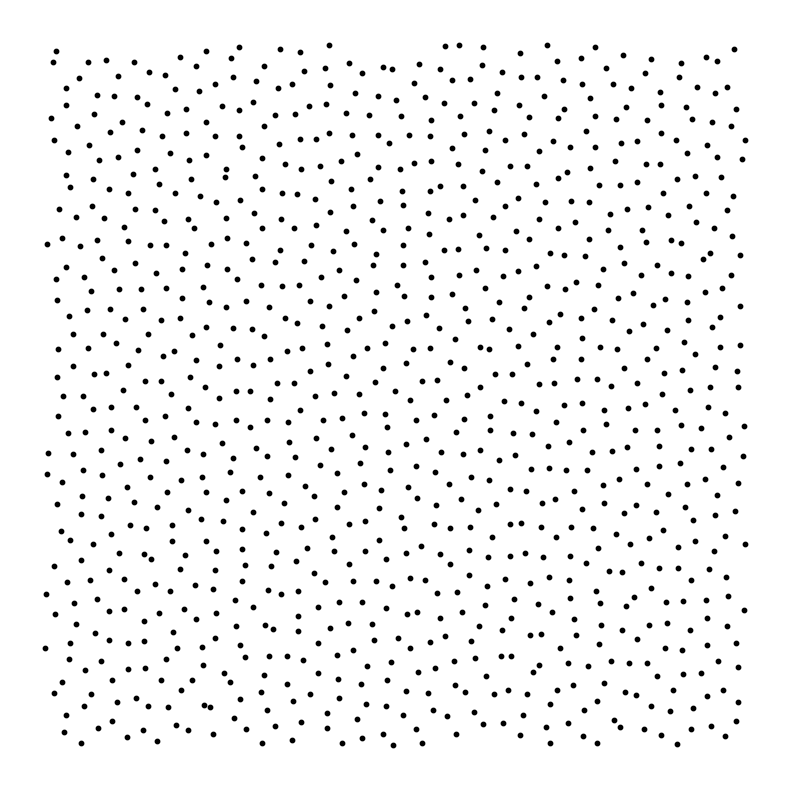

In [75]:
blue.plot(x, auto_zoom = True, max_points = 1000)

# Note the influence of the Chi parametter
which control the last frequency at wich we require S(k) << 1. Big Chi means more frequencies are controlled, but at the cost of a lower precision. Chi shall not go far beyond 0.5, because above we would ask more equation than the number of free parametters. Default value is Chi = 0.4

2D - Chi: 0.4
2D - Chi: 0.5
2D - Chi: 0.7


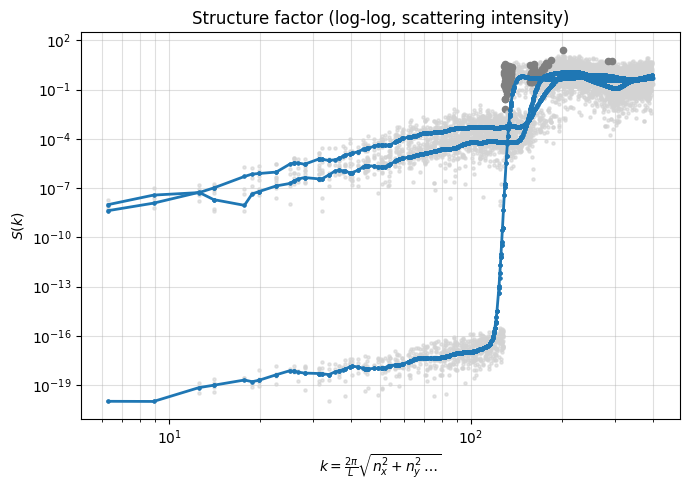

3D - Chi: 0.4
3D - Chi: 0.5
3D - Chi: 0.7


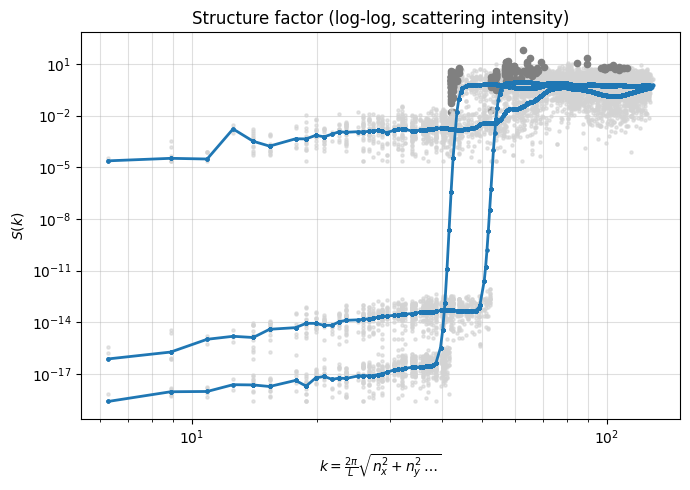

In [76]:
jax.config.update("jax_enable_x64", True) #float64 precision to see how far it can go (default float32 would not be enough to capture S(k) <= 10**-10)

N = 1_000
for D in [2, 3]:
    ax = None
    for Chi in  [0.4, 0.5, 0.7]:
        print(f"{D}D - Chi: {Chi}")
        x = sample_blue_jax_finufft(N = N, D = D, Chi = Chi, verbose = 0)
        fig, ax = blue.plot_structure_factor(x, ax = ax, return_fig = True)
    import matplotlib.pyplot as plt
    plt.show()

if precision == "simple": #put back the old float32 precision
    jax.config.update("jax_enable_x64", False)